In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

plt.style.use("ggplot")

Matplotlib is building the font cache; this may take a moment.


In [6]:
nav_df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

In [7]:
nav_df.head()


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [8]:
nav_df.columns.tolist()

['amfi_code', 'date', 'nav']

In [9]:
nav_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [10]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

In [11]:
nav_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [12]:
nav_df["amfi_code"].nunique()

40

In [13]:
fig = px.line(
    nav_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "Net Asset Value (NAV)",
        "amfi_code": "AMFI Code"
    }
)

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=700,
    legend_title="Mutual Fund Schemes"
)

fig.show()

Insight 1
The daily NAV of most mutual fund schemes showed a steady upward trend from 2022 to 2026. A strong market rally was visible during 2023, while 2024 experienced periods of market correction.

In [14]:
fig = px.line(
    nav_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "Net Asset Value (NAV)",
        "amfi_code": "AMFI Code"
    }
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="lightgreen",
    opacity=0.2,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="lightcoral",
    opacity=0.2,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=700,
    legend_title="AMFI Code"
)

fig.show()

In [15]:
aum_df = pd.read_csv("../data/processed/03_aum_by_fund_house_cleaned.csv")

In [16]:
aum_df.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [17]:
aum_df.columns.tolist()

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

In [18]:
aum_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 3.6 KB


In [19]:
aum_df["date"] = pd.to_datetime(aum_df["date"])

In [20]:
aum_df["year"] = aum_df["date"].dt.year

In [21]:
aum_df["year"].unique()

array([2022, 2023, 2024, 2025], dtype=int32)

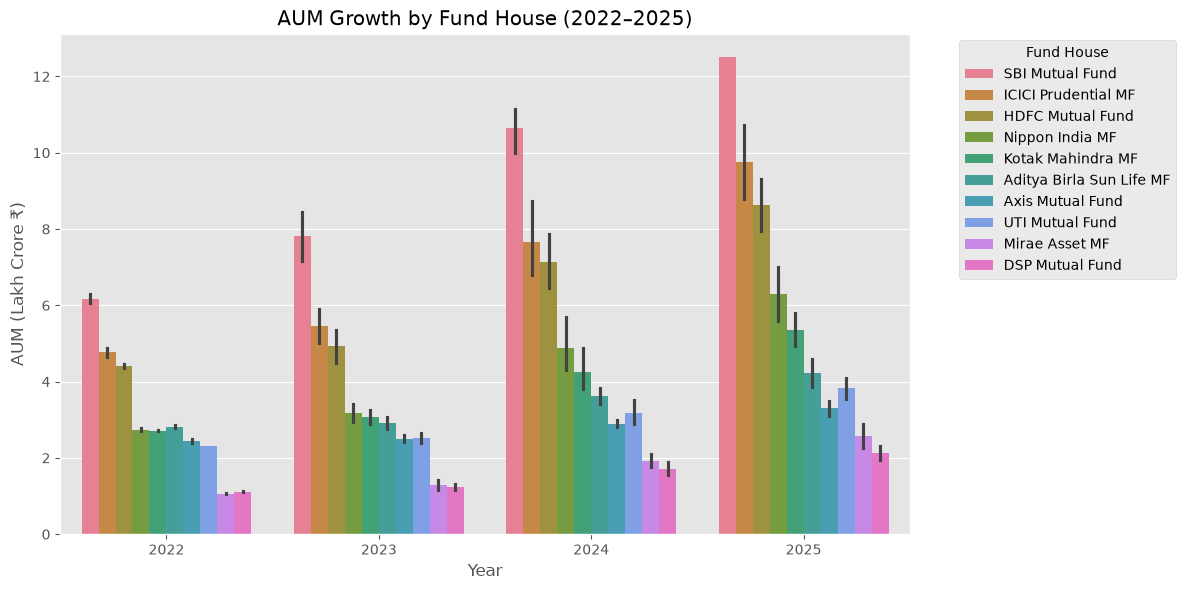

In [22]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum_df,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")
plt.xticks(rotation=0)

plt.legend(title="Fund House", bbox_to_anchor=(1.05,1), loc="upper left")

plt.tight_layout()
plt.show()

Insight 2
SBI Mutual Fund maintained one of the highest Assets Under Management (AUM) among all fund houses, demonstrating its strong market presence.

In [23]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=aum_df,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=15, weight="bold")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")

# Highlight SBI
sbi_data = aum_df[aum_df["fund_house"] == "SBI Mutual Fund"]

for _, row in sbi_data.iterrows():
    plt.text(
        row["year"],
        row["aum_lakh_crore"] + 0.2,
        f"{row['aum_lakh_crore']:.1f}",
        ha="center",
        fontsize=9,
        color="red",
        fontweight="bold"
    )

plt.legend(title="Fund House", bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()
plt.show()

C:\Users\parik\AppData\Local\Temp\ipykernel_6948\336856972.py:30: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


In [24]:
plt.savefig("../reports/charts/aum_growth.png", dpi=300, bbox_inches="tight")

FileNotFoundError: [Errno 2] No such file or directory: '../reports/charts/aum_growth.png'

<Figure size 640x480 with 0 Axes>

In [26]:
from pathlib import Path

Path("../reports/charts").mkdir(parents=True, exist_ok=True)

In [27]:
plt.savefig("../reports/charts/aum_growth.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [28]:
sip_df = pd.read_csv("../data/processed/04_monthly_sip_inflows_cleaned.csv")

In [29]:
sip_df.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [30]:
sip_df.columns.tolist()

['month',
 'sip_inflow_crore',
 'active_sip_accounts_crore',
 'new_sip_accounts_lakh',
 'sip_aum_lakh_crore',
 'yoy_growth_pct']

In [31]:
sip_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     str    
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.4 KB


In [32]:
sip_df["month"] = pd.to_datetime(sip_df["month"])

In [33]:
fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (Jan 2022 – Dec 2025)",
    markers=True
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    width=1200,
    height=600
)

fig.show()

Insight 3
Monthly SIP inflows increased consistently over the years and reached their peak in December 2025, indicating growing investor confidence.

In [34]:
fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (Jan 2022 – Dec 2025)"
)

max_row = sip_df.loc[sip_df["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"Peak: ₹{max_row['sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    width=1200,
    height=600
)

fig.show()

In [35]:
category_df = pd.read_csv("../data/processed/05_category_inflows_cleaned.csv")

In [36]:
category_df.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [37]:
category_df.columns.tolist()

['month', 'category', 'net_inflow_crore']

In [38]:
category_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    str    
 1   category          144 non-null    str    
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), str(2)
memory usage: 3.5 KB


In [39]:
category_df["month"] = pd.to_datetime(category_df["month"])

In [40]:
category_df["month_label"] = category_df["month"].dt.strftime("%b-%Y")

In [41]:
category_df.head()

,month,category,net_inflow_crore,month_label
0,2024-04-01,Large Cap,2413.0,Apr-2024
1,2024-04-01,Mid Cap,3897.0,Apr-2024
2,2024-04-01,Small Cap,3533.0,Apr-2024
3,2024-04-01,Flexi Cap,4947.0,Apr-2024
4,2024-04-01,Large & Mid Cap,4214.0,Apr-2024


In [42]:
heatmap_data = category_df.pivot(
    index="category",
    columns="month_label",
    values="net_inflow_crore"
)

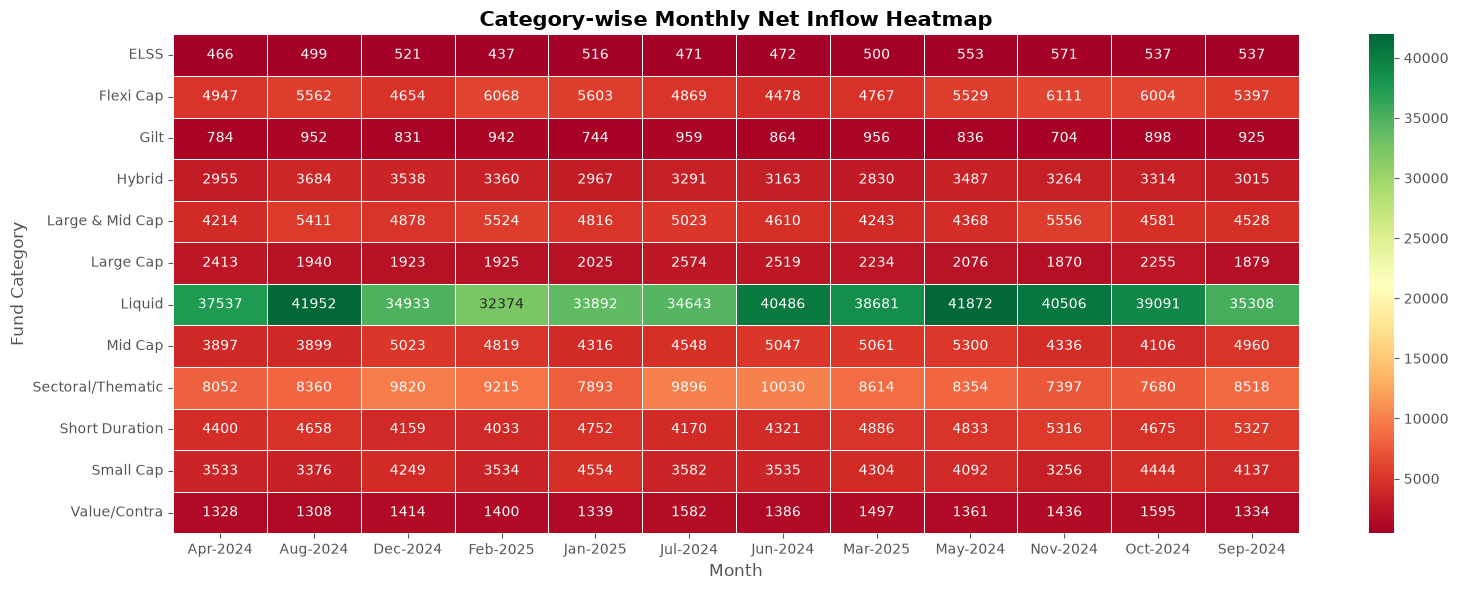

In [43]:
plt.figure(figsize=(16,6))

sns.heatmap(
    heatmap_data,
    cmap="RdYlGn",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Category-wise Monthly Net Inflow Heatmap", fontsize=15, weight="bold")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()
plt.show()

Insight 4
Different fund categories experienced varying monthly inflows, with equity-oriented categories attracting higher investments during bullish market periods.

In [46]:
investor_df = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

In [47]:
investor_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [48]:
investor_df.columns.tolist()

['investor_id',
 'transaction_date',
 'amfi_code',
 'transaction_type',
 'amount_inr',
 'state',
 'city',
 'city_tier',
 'age_group',
 'gender',
 'annual_income_lakh',
 'payment_mode',
 'kyc_status']

In [49]:
investor_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 3.3 MB


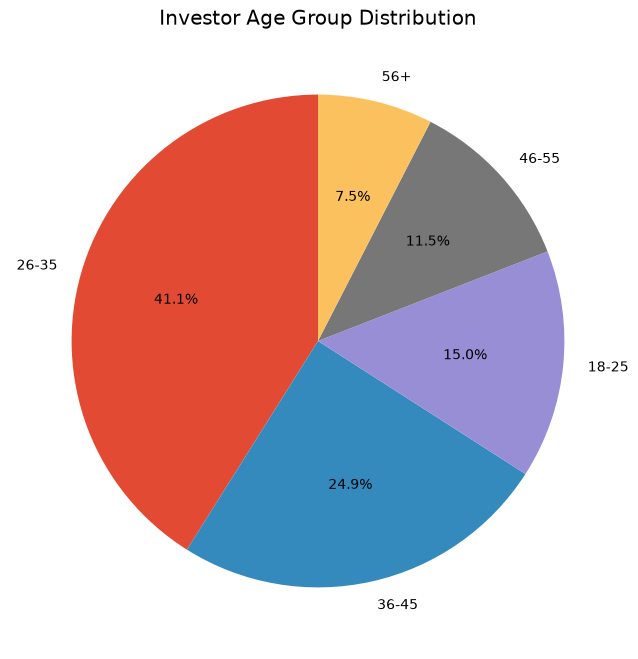

In [50]:
plt.figure(figsize=(8,8))

age_counts = investor_df["age_group"].value_counts()

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.show()

Insight 5
Most investors belonged to the working-age population, showing that salaried professionals contribute significantly to mutual fund investments.

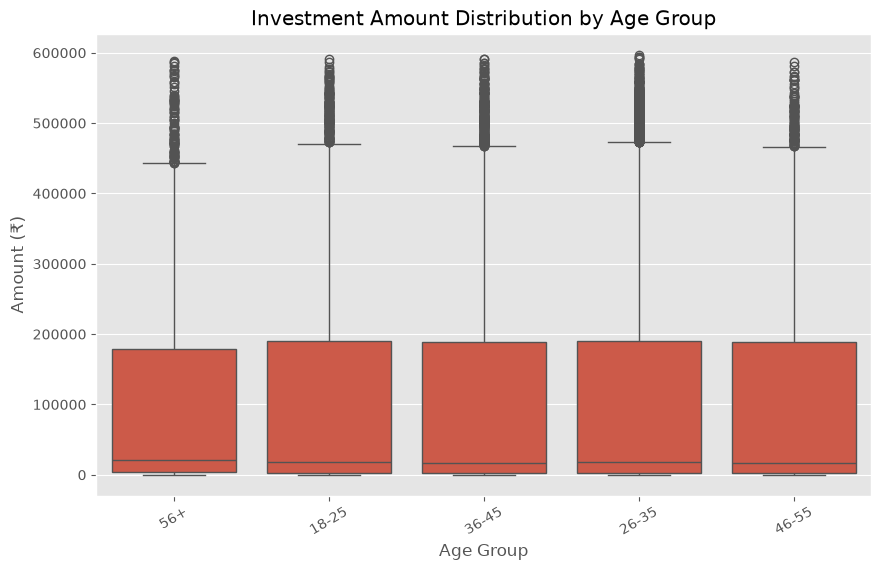

In [51]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor_df,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (₹)")

plt.xticks(rotation=30)

plt.show()

Insight 6
Investment amounts varied across different age groups, with some groups making larger and more diverse investments.

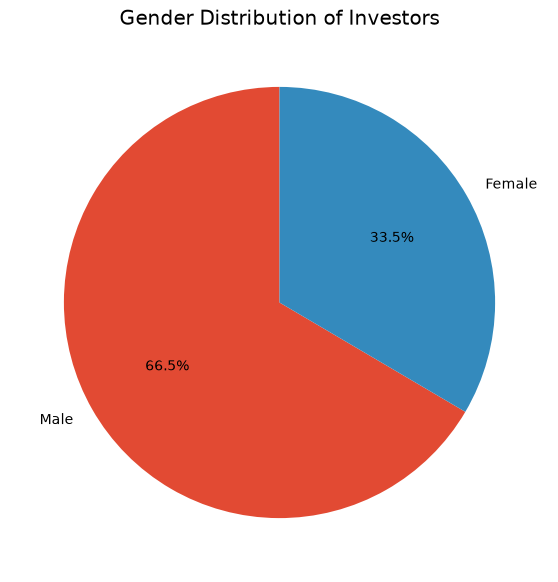

In [52]:
plt.figure(figsize=(7,7))

gender_counts = investor_df["gender"].value_counts()

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")

plt.show()

Insight 7
The gender distribution highlighted the participation of both male and female investors in mutual fund investments.

In [53]:
state_sip = investor_df.groupby("state")["amount_inr"].sum().sort_values(ascending=False)

C:\Users\parik\AppData\Local\Temp\ipykernel_6948\1904081502.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


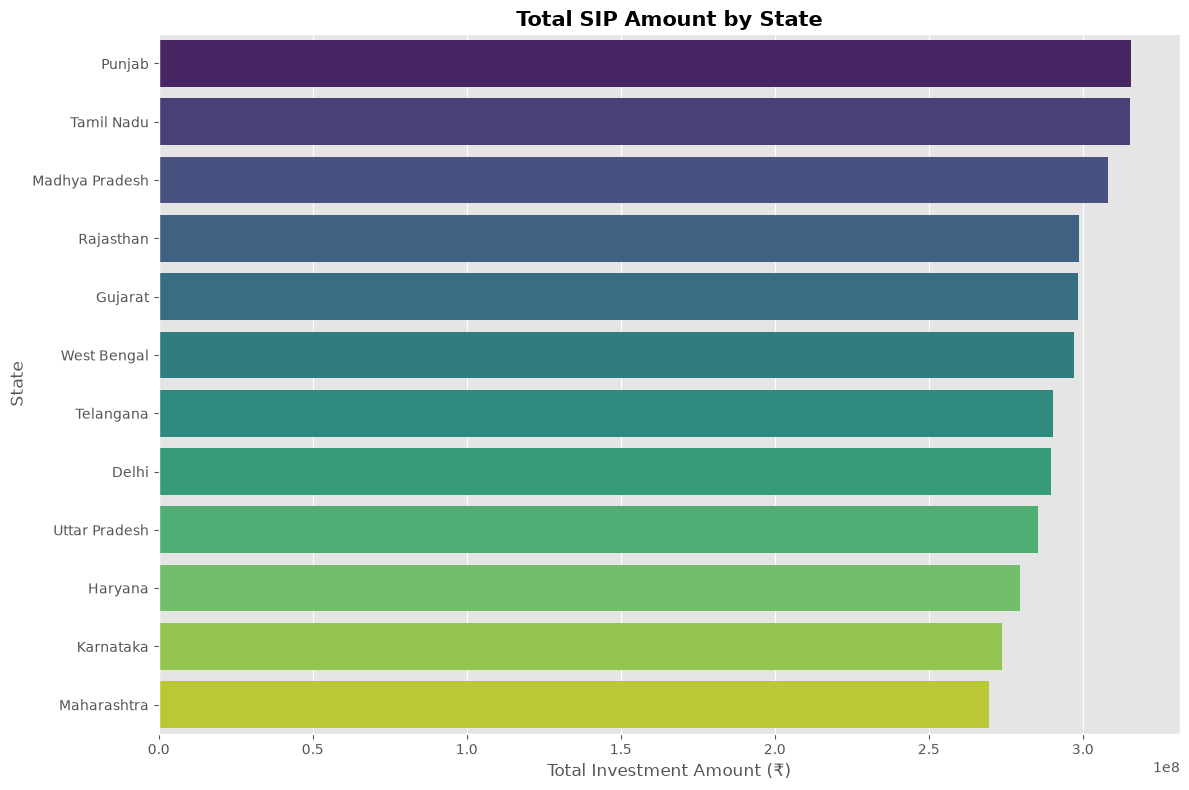

In [54]:
plt.figure(figsize=(12,8))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index,
    palette="viridis"
)

plt.title("Total SIP Amount by State", fontsize=15, weight="bold")
plt.xlabel("Total Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [55]:
city_counts = investor_df["city_tier"].value_counts()

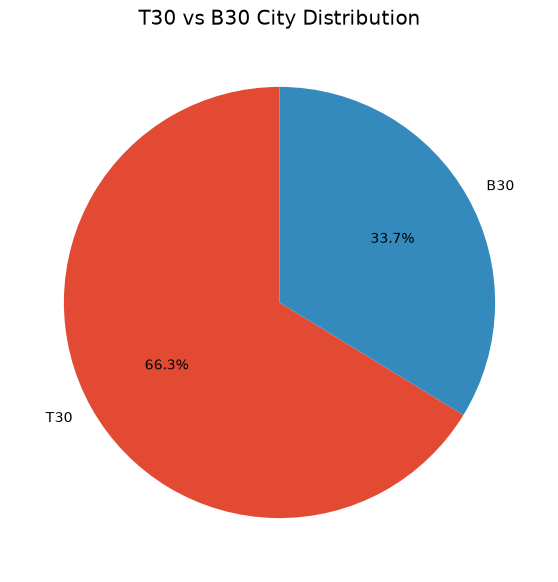

In [56]:
plt.figure(figsize=(7,7))

plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Distribution")

plt.show()


Insight 8
A major portion of mutual fund investments originated from T30 cities, while several states contributed significantly to the overall investment volume.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [3]:
folio_df = pd.read_csv("../data/processed/06_industry_folio_count_cleaned.csv")

In [4]:

folio_df.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [5]:
folio_df.columns.tolist()

['month',
 'total_folios_crore',
 'equity_folios_crore',
 'debt_folios_crore',
 'hybrid_folios_crore',
 'others_folios_crore']

In [6]:
folio_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     str    
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), str(1)
memory usage: 1.1 KB


In [7]:
folio_df["month"] = pd.to_datetime(folio_df["month"])

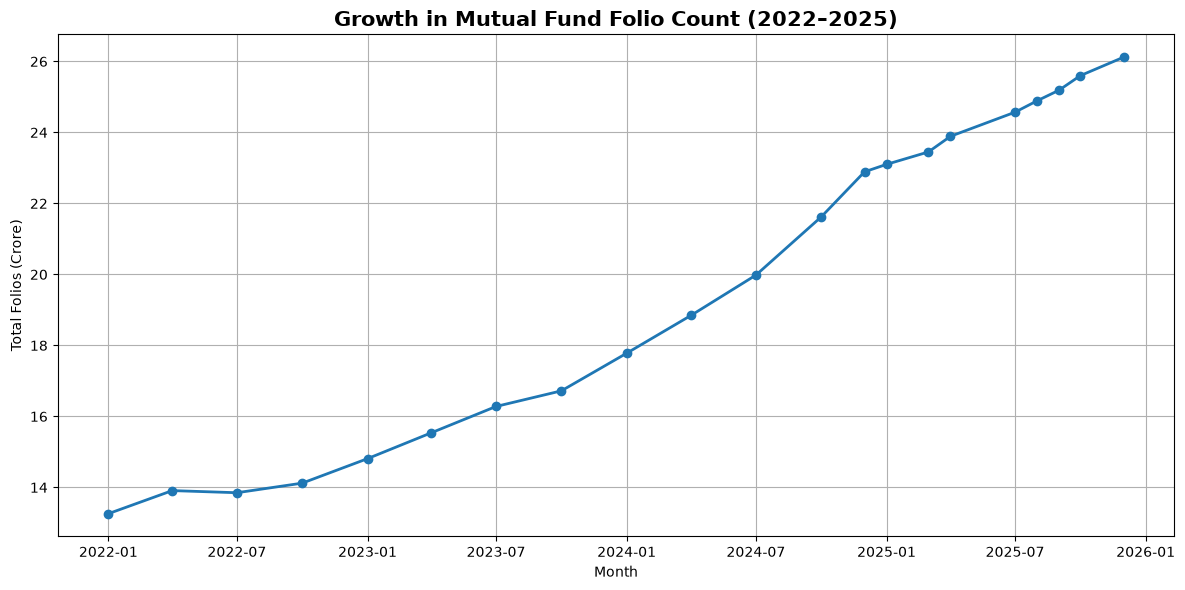

In [8]:
plt.figure(figsize=(12,6))

plt.plot(
    folio_df["month"],
    folio_df["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Growth in Mutual Fund Folio Count (2022–2025)", fontsize=15, weight="bold")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

plt.tight_layout()
plt.show()

Insight 9
The total number of mutual fund folios increased steadily over the analysis period, reflecting continuous growth in retail investor participation.

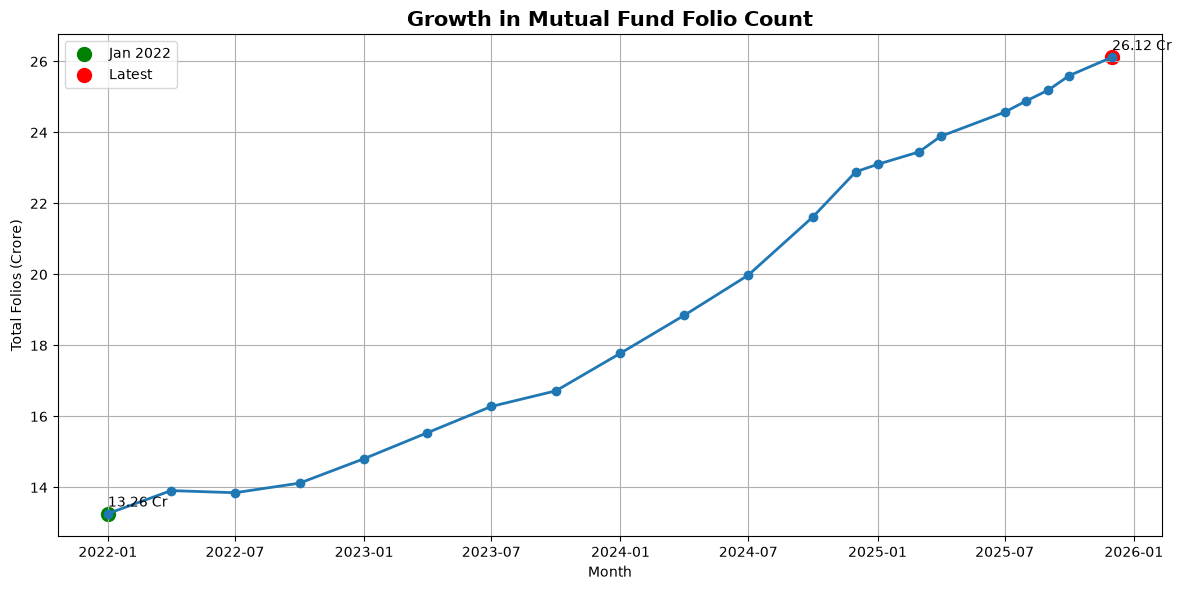

In [9]:
plt.figure(figsize=(12,6))

plt.plot(
    folio_df["month"],
    folio_df["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.scatter(
    folio_df.iloc[0]["month"],
    folio_df.iloc[0]["total_folios_crore"],
    color="green",
    s=100,
    label="Jan 2022"
)

plt.scatter(
    folio_df.iloc[-1]["month"],
    folio_df.iloc[-1]["total_folios_crore"],
    color="red",
    s=100,
    label="Latest"
)

plt.text(
    folio_df.iloc[0]["month"],
    folio_df.iloc[0]["total_folios_crore"] + 0.2,
    f'{folio_df.iloc[0]["total_folios_crore"]:.2f} Cr'
)

plt.text(
    folio_df.iloc[-1]["month"],
    folio_df.iloc[-1]["total_folios_crore"] + 0.2,
    f'{folio_df.iloc[-1]["total_folios_crore"]:.2f} Cr'
)

plt.title("Growth in Mutual Fund Folio Count", fontsize=15, weight="bold")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
nav_df.head()

NameError: name 'nav_df' is not defined

In [11]:
import pandas as pd

In [12]:
nav_df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

In [13]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

In [14]:
nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [15]:
portfolio_df = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")

In [16]:
portfolio_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [17]:
portfolio_df.columns.tolist()

['amfi_code',
 'stock_symbol',
 'stock_name',
 'sector',
 'weight_pct',
 'market_value_cr',
 'current_price_inr',
 'portfolio_date']

In [18]:

portfolio_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [19]:
nav_df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
nav_df["date"] = pd.to_datetime(nav_df["date"])

In [20]:
selected_funds = nav_df["amfi_code"].unique()[:10]

corr_df = nav_df[nav_df["amfi_code"].isin(selected_funds)].copy()

In [21]:
pivot_df = corr_df.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

In [22]:
returns = pivot_df.pct_change().dropna()

In [23]:
corr_matrix = returns.corr()

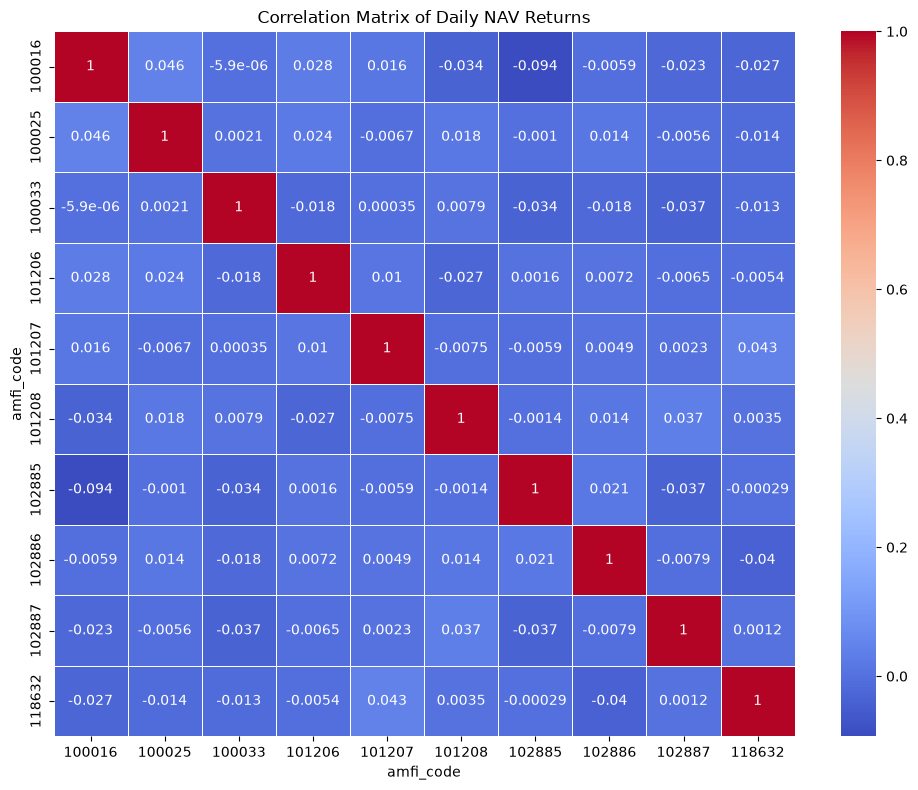

In [24]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.tight_layout()
plt.show()

In [25]:
sector_df = portfolio_df.groupby("sector")["weight_pct"].sum().reset_index()

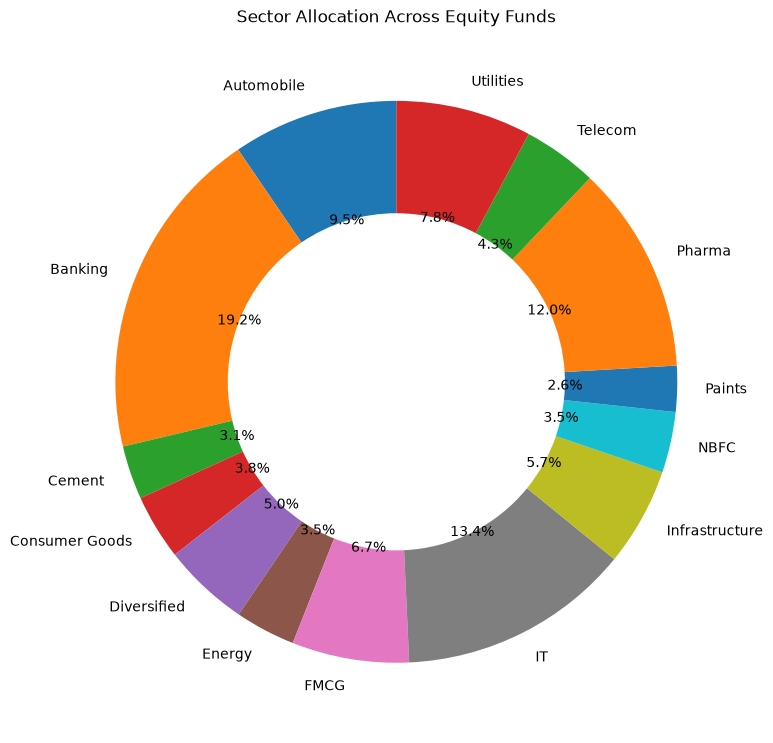

In [26]:
plt.figure(figsize=(8,8))

plt.pie(
    sector_df["weight_pct"],
    labels=sector_df["sector"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.tight_layout()
plt.show()

Insight 10
Sector allocation remained diversified across banking, utilities, pharma, and other sectors, helping reduce portfolio concentration risk.